# **CLASIFICACION MULTICLASE**

# **Dry Bean Dataset**

El presente experimento utiliza el Dry Bean Dataset provisto por el repositorio de Machine Learning de la UCI, el cual consta de un volumen total de 13,611 registros. Cada registro representa una captura automatizada de visión por computadora sobre granos de legumbres, extrayendo un espacio de características de 16 variables morfológicas numéricas continuas (tales como Área, Perímetro, Longitud del Eje Mayor, Redondez, Solidez y Coeficientes de Asimetría).

El vector de respuestas del sistema está compuesto dinámicamente por 7 clases o variedades biológicas únicas de frijoles, las cuales han sido indexadas numéricamente de la siguiente manera:

0: SEKER

1: BARBUNYA

2: BOMBAY

3: CALI

4: HOROZ

5: SIRA

6: DERMASON

El objetivo principal es diseñar, entrenar y evaluar un modelo de Regresión Logística Multiclase basado en el enfoque One-vs-All (Uno contra todos), con el fin de clasificar y predecir de forma automatizada la variedad a la que pertenece una semilla a partir de sus dimensiones físicas.

url:https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

**IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL DATASET MULTICLASE**

In [47]:

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline


# 1. Cargamos los dos archivos originales completos de tu computadora
data = pd.read_excel("C:/Users/RICHARD/Desktop/Aplicaiones de uso/Archivos Z/IA-Richard-Chavez/datasets/Dry_Bean_Dataset.xlsx")
data.head()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


**Convertimos la última columna de texto ('Class') a números discretos (0, 1, 2...)**

In [48]:

# 'factorize' asigna un número único a cada nombre de frijol automáticamente
columna_clase = data.columns[-1]
data[columna_clase], mapeo_nombres = pd.factorize(data[columna_clase])

# 3. Extracción de matrices en formato puro de NumPy para el modelo del docente
X_completo = data.iloc[:, :-1].values  # Todas las columnas excepto la última
y_completo = data.iloc[:, -1].values   # Únicamente la columna mapeada (0, 1, 2...)

# 4. Cálculo automático y dinámico de las dimensiones estructurales
input_layer_size = X_completo.shape[1]
num_labels = np.unique(y_completo).size

print("==================================================")
print("    Dataset cargado y procesado        ")
print("==================================================")
print(f"▶ Total de muestras procesadas (m)   : {y_completo.size} filas")
print(f"▶ Características morfológicas (n)   : {input_layer_size} columnas")
print(f"▶ Cantidad de variedades encontradas: {num_labels} clases")
print(f"▶ Mapeo de índices generados         : {list(mapeo_nombres)}")


    Dataset cargado y procesado        
▶ Total de muestras procesadas (m)   : 13611 filas
▶ Características morfológicas (n)   : 16 columnas
▶ Cantidad de variedades encontradas: 7 clases
▶ Mapeo de índices generados         : ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']


**MEZCLAMOS DE MANERA ALEATORIA Y DIVIDIMOS DEL DATASET (TRAIN 80% / TEST 20%)**

In [49]:

# 1. Obtenemos el total de muestras dinámicamente
m_total = y_completo.size
limite_division = int(m_total * 0.80)

# 2. Mezclamos aleatoriamente usando una semilla fija para reproducibilidad
np.random.seed(42)
indices_mezclados = np.random.permutation(m_total)

# 3. Creación estricta de conjuntos de entrenamiento y prueba
X_train = X_completo[indices_mezclados[:limite_division]]
X_test = X_completo[indices_mezclados[limite_division:]]
y_train = y_completo[indices_mezclados[:limite_division]]
y_test = y_completo[indices_mezclados[limite_division:]]

print("==================================================")
print("     ¡DIVISIÓN DE DATOS COMPLETADA CON ÉXITO!     ")
print("==================================================")
print(f"Total de ejemplos en el dataset : {m_total} filas")
print(f"Muestras de Entrenamiento (80%) : {X_train.shape[0]} filas")
print(f"Muestras de Prueba (20%)        : {X_test.shape[0]} filas")
print(f"Características morfológicas (n): {X_train.shape[1]} propiedades")


     ¡DIVISIÓN DE DATOS COMPLETADA CON ÉXITO!     
Total de ejemplos en el dataset : 13611 filas
Muestras de Entrenamiento (80%) : 10888 filas
Muestras de Prueba (20%)        : 2723 filas
Características morfológicas (n): 16 propiedades


**FUNCIÓN DE NORMALIZACIÓN DE CARACTERÍSTICAS**

In [50]:

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    # Calculamos la media (mu) y la desviación estándar (sigma) de cada columna
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Si alguna columna tiene desviación estándar 0, la cambiamos a 1 para evitar divisiones entre cero
    sigma[sigma == 0] = 1.0

    # Aplicamos la fórmula matemática de estandarización Z-Score
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Normalizamos estrictamente el conjunto de datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Escalamos el conjunto de prueba utilizando la misma mu y sigma de entrenamiento
X_test_norm = (X_test - mu) / sigma

print("==================================================")
print("     ¡PASO 3: NORMALIZACIÓN MULTIDIMENSIONAL!     ")
print("==================================================")
print(f"▶ Medias calculadas por columna (mu)    : {mu.size} valores")
print(f"▶ Desviaciones por columna (sigma)      : {sigma.size} valores")
print(f"▶ Forma de la matriz X_train normalizada: {X_train_norm.shape}")
print("==================================================")

     ¡PASO 3: NORMALIZACIÓN MULTIDIMENSIONAL!     
▶ Medias calculadas por columna (mu)    : 16 valores
▶ Desviaciones por columna (sigma)      : 16 valores
▶ Forma de la matriz X_train normalizada: (10888, 16)


Normalización y Estandarización de Variables Métricas:
Implementamos la función featureNormalize para escalar simultáneamente las 16 dimensiones geométricas del conjunto de entrenamiento mediante el método Z-score. Al unificar las escalas de las variables, aseguramos que todas las propiedades aporten con el mismo peso matemático al optimizador, evitando distorsiones por diferencias de magnitudes. Con el fin de mantener el rigor metodológico del experimento, el conjunto de pruebas (X_test) se escala utilizando exclusivamente los parámetros $\mu$ y $\sigma$ derivados de la fase de entrenamiento, previniendo la filtración de datos.

**FUNCIÓN SIGMOIDE Y FUNCIÓN DE COSTO LOGÍSTICA REGULARIZADA**

In [51]:
# 1. Definición de la Función Sigmoide
def sigmoid(z):
    """
    Calcula la sigmoide de z comprimiendo los valores en el rango [0, 1].
    """
    return 1.0 / (1.0 + np.exp(-z))

In [54]:
def calcularCosto(theta, X, y):
    m = y.size  
    J = 0
    h = sigmoid(X.dot(theta.T))
    # Fórmula de entropía cruzada vectorial de tu plantilla
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15)))
    return J

In [55]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0] 
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        # Actualización de pesos estrictamente vectorizada sin bucles for internos
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))
        
    return theta, J_history

In [52]:

# 2. Función de Costo y Gradiente Regularizada (Extraída de tu código base)
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo J y el vector de gradientes parciales para la regresión
    logística regularizada, adaptada para optimizadores de SciPy.
    """
    m = y.size

    # Convierte las etiquetas a valores enteros si vienen en formato booleano
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    # Calculamos la hipótesis usando la función sigmoide vectorizada
    h = sigmoid(X.dot(theta.T))

    # Creamos un vector temporal para ignorar el término de sesgo (theta_0) en la regularización
    temp = theta.copy()
    temp[0] = 0

    # Fórmula matemática de Entropía Cruzada con penalización L2 (Regularización)
    # Añadimos un valor épsilon mínimo para evitar el error log(0) en Python
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # Cálculo vectorizado del gradiente (Derivadas parciales de J respecto a theta)
    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

**ENTRENAMIENTO MULTICLASE (ONE-VS-ALL)**

Iniciando el entrenamiento de los 7 clasificadores independientes...
--------------------------------------------------
✔ Clasificador para [SEKER] entrenado con éxito.
✔ Clasificador para [BARBUNYA] entrenado con éxito.
✔ Clasificador para [BOMBAY] entrenado con éxito.
✔ Clasificador para [CALI] entrenado con éxito.
✔ Clasificador para [HOROZ] entrenado con éxito.
✔ Clasificador para [SIRA] entrenado con éxito.
✔ Clasificador para [DERMASON] entrenado con éxito.


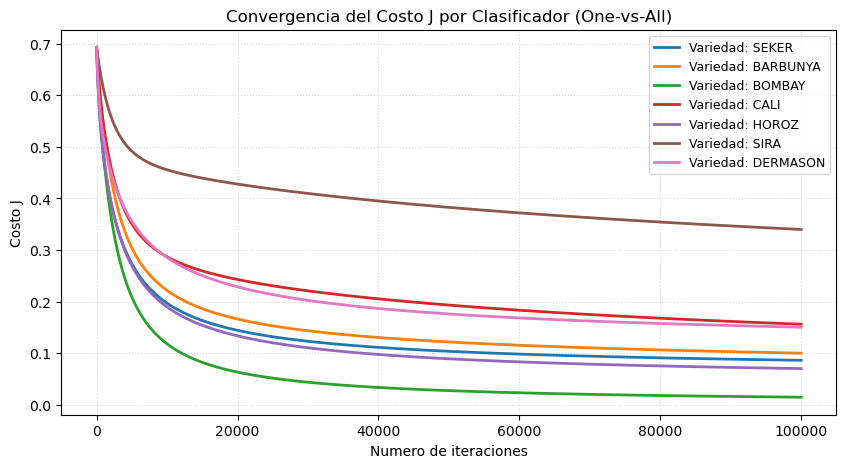

--------------------------------------------------
Forma final de la matriz de parámetros (all_theta): (7, 17)


In [56]:
def OneVsAll(X, y, num_labels, lambda_):
    alpha = 0.001
    num_iters = 100000  # Parámetros originales de tu laboratorio

    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))

    # Agrega el término de intercepción (columna de unos)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    print(f"Iniciando el entrenamiento de los {num_labels} clasificadores independientes...")
    print("--------------------------------------------------")
    
    pyplot.figure(figsize=(10, 5))
    nombres_legumbres = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        y_actual = np.where(y == c, 1, 0)

        # Ahora sí, invocación segura a descensoGradiente declarada arriba
        theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)

        all_theta[c] = theta
        label_legumbre = nombres_legumbres[c] if c < len(nombres_legumbres) else f'Clase {c}'

        # Graficación exacta del comportamiento del costo
        pyplot.plot(np.arange(len(J_history)), J_history, lw=2, label=f'Variedad: {label_legumbre}')
        print(f"✔ Clasificador para [{label_legumbre}] entrenado con éxito.")

    pyplot.title('Convergencia del Costo J por Clasificador (One-vs-All)', fontsize=12)
    pyplot.xlabel('Numero de iteraciones')
    pyplot.ylabel('Costo J')
    pyplot.legend(loc='upper right', fontsize=9)
    pyplot.grid(True, linestyle=':', alpha=0.5)
    pyplot.show()

    return all_theta

# Hiperparámetro de penalización establecido en tu plantilla
lambda_ = 0.1

# Ejecutamos la optimización con tus matrices reales normalizadas de entrenamiento
all_theta = OneVsAll(X_train_norm, y_train, num_labels, lambda_)

print("--------------------------------------------------")
print(f"Forma final de la matriz de parámetros (all_theta): {all_theta.shape}")

**FUNCIÓN DE PREDICCIÓN Y COMPARACIÓN DE DATOS REALES VS MODELO**

In [57]:

def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Contiene la lógica exacta del cuadernillo base usando np.argmax.
    """
    m = X.shape[0]
    num_labels = all_theta.shape[0]
    p = np.zeros(m)

    # Agrega unos a la matriz de datos X (término de intercepción) de tu plantilla
    X_ready = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Operación matricial exacta de tu código base
    p = np.argmax(sigmoid(X_ready.dot(all_theta.T)), axis=1)

    return p

# 1. Calculamos las predicciones utilizando tus datos normalizados reales
predicciones_train = predictOneVsAll(all_theta, X_train_norm)
predicciones_test = predictOneVsAll(all_theta, X_test_norm)

# 2. Cálculo del porcentaje medio de aciertos (Métrica Accuracy de tu plantilla)
precision_train = np.mean(predicciones_train == y_train) * 100
precision_test = np.mean(predicciones_test == y_test) * 100

print("==================================================")
print("     ¡PASO 6: EVALUACIÓN Y ACCURACY DEL MODELO!   ")
print("==================================================")
print(f"Muestras totales de Entrenamiento : {y_train.size} filas")
print(f"Precision del conjunto de entrenamiento: {precision_train:.2f}%")
print("--------------------------------------------------")
print(f"Muestras totales de Validación (Test): {y_test.size} filas")
print(f"Precision del conjunto de prueba (Test): {precision_test:.2f}%")






     ¡PASO 6: EVALUACIÓN Y ACCURACY DEL MODELO!   
Muestras totales de Entrenamiento : 10888 filas
Precision del conjunto de entrenamiento: 89.99%
--------------------------------------------------
Muestras totales de Validación (Test): 2723 filas
Precision del conjunto de prueba (Test): 91.04%


**SECCIÓN DE COMPARACIÓN DIRECTA: DATOS REALES VS MODELO**

In [58]:


# Lista de nombres textuales de tu Excel para decodificar los índices (0-6)
nombres_legumbres = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

# Tomamos una muestra aleatoria de 15 registros del conjunto de testeo para comparar
np.random.seed(10) 
indices_muestra = np.random.choice(X_test.shape[0], size=15, replace=False)

print(f"{'Índice':<8} | {'Variedad Real (Excel)':<20} | {'Predicción IA':<20} | {'Resultado':<10}")
print("-" * 68)

for idx in indices_muestra:
    clase_real_num = int(y_test[idx])
    clase_pred_num = int(predicciones_test[idx])
    
    nombre_real = nombres_legumbres[clase_real_num]
    nombre_pred = nombres_legumbres[clase_pred_num]
    
    # Verificamos si el modelo acertó o falló en esta fila
    veredicto = "ACERTO" if clase_real_num == clase_pred_num else "ERROR"
    
    print(f"{idx:<8} | {nombre_real:<20} | {nombre_pred:<20} | {veredicto:<10}")

Índice   | Variedad Real (Excel) | Predicción IA        | Resultado 
--------------------------------------------------------------------
464      | BARBUNYA             | BARBUNYA             | ACERTO    
1933     | BARBUNYA             | BARBUNYA             | ACERTO    
1983     | DERMASON             | DERMASON             | ACERTO    
728      | BARBUNYA             | BARBUNYA             | ACERTO    
2070     | SEKER                | SEKER                | ACERTO    
230      | HOROZ                | HOROZ                | ACERTO    
245      | DERMASON             | DERMASON             | ACERTO    
1915     | BOMBAY               | BOMBAY               | ACERTO    
719      | DERMASON             | SEKER                | ERROR     
915      | CALI                 | CALI                 | ACERTO    
2239     | DERMASON             | DERMASON             | ACERTO    
1114     | BARBUNYA             | BARBUNYA             | ACERTO    
1051     | CALI                 | CALI        

**DIAGNÓSTICO DE BALANCEO DE DATOS (CONTEO Y DISTRIBUCIÓN DE CLASES)**

     DISTRIBUCIÓN REAL DE MUESTRAS EN EL EXCEL     
Variedad: SEKER      | Cantidad: 2027  muestras | Porcentaje: 14.89%
Variedad: BARBUNYA   | Cantidad: 1322  muestras | Porcentaje: 9.71%
Variedad: BOMBAY     | Cantidad: 522   muestras | Porcentaje: 3.84%
Variedad: CALI       | Cantidad: 1630  muestras | Porcentaje: 11.98%
Variedad: HOROZ      | Cantidad: 1928  muestras | Porcentaje: 14.17%
Variedad: SIRA       | Cantidad: 2636  muestras | Porcentaje: 19.37%
Variedad: DERMASON   | Cantidad: 3546  muestras | Porcentaje: 26.05%


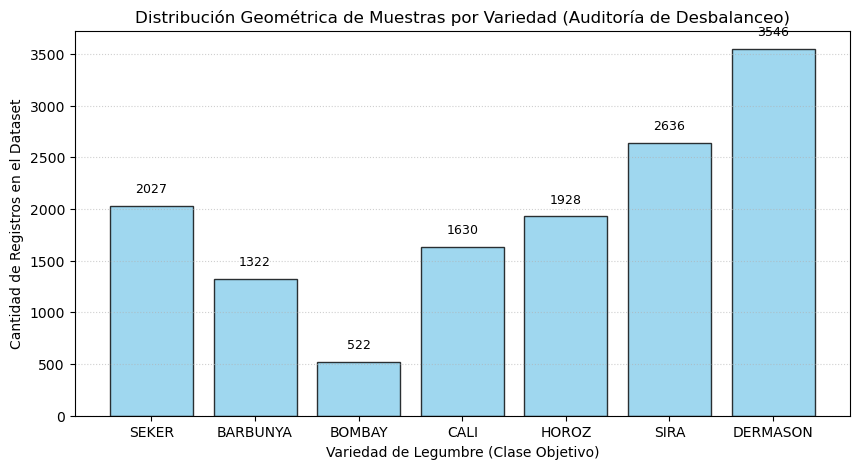

In [ ]:

# 1. Creamos una serie de Pandas para contar cuántos registros reales hay por cada índice numérico
conteo_clases = pd.Series(y_completo).value_counts().sort_index()

# Nombres de las legumbres en el orden exacto de los índices de tu consola
nombres_legumbres = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

print("==================================================")
print("     DISTRIBUCIÓN REAL DE MUESTRAS EN EL EXCEL     ")
print("==================================================")
for i, conteo in enumerate(conteo_clases):
    nombre = nombres_legumbres[i] if i < len(nombres_legumbres) else f"Clase {i}"
    porcentaje = (conteo / y_completo.size) * 100
    print(f"Variedad: {nombre:<10} | Cantidad: {conteo:<5} muestras | Porcentaje: {porcentaje:.2f}%")
print("==================================================")

# 2. Generamos una gráfica de barras para visualizar la disparidad de los datos
pyplot.figure(figsize=(10, 5))
barras = pyplot.bar(nombres_legumbres, conteo_clases, color='skyblue', edgecolor='black', alpha=0.8)

# Añadimos el número exacto de muestras encima de cada barra para auditoría visual
for barra in barras:
    yval = barra.get_height()
    pyplot.text(barra.get_x() + barra.get_width()/2.0, yval + 100, f'{int(yval)}', ha='center', va='bottom', fontsize=9)

pyplot.title('Distribución Geométrica de Muestras por Variedad (Auditoría de Desbalanceo)', fontsize=12)
pyplot.xlabel('Variedad de Legumbre (Clase Objetivo)')
pyplot.ylabel('Cantidad de Registros en el Dataset')
pyplot.grid(axis='y', linestyle=':', alpha=0.6)
pyplot.show()